In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv('/content/WA_Fn-UseC_-IT-Help-Desk.csv')

# Display first rows
data.head()

,ticket,requestor,RequestorSeniority,ITOwner,FiledAgainst,TicketType,Severity,Priority,daysOpen,Satisfaction
0,1,1929,1 - Junior,50,Systems,Issue,2 - Normal,0 - Unassigned,3,1 - Unsatisfied
1,2,1587,2 - Regular,15,Software,Request,1 - Minor,1 - Low,5,1 - Unsatisfied
2,3,925,2 - Regular,15,Access/Login,Request,2 - Normal,0 - Unassigned,0,0 - Unknown
3,4,413,4 - Management,22,Systems,Request,2 - Normal,0 - Unassigned,20,0 - Unknown
4,5,318,1 - Junior,22,Access/Login,Request,2 - Normal,1 - Low,1,1 - Unsatisfied


In [10]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = text.split()

    # Stopword removal
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
# The 'description' column was not found. Using 'FiledAgainst' instead.
data['clean_text'] = data['FiledAgainst'].apply(preprocess)

data[['FiledAgainst','clean_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,FiledAgainst,clean_text
0,Systems,systems
1,Software,software
2,Access/Login,access login
3,Systems,systems
4,Access/Login,access login


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into numerical features
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data['clean_text'])

X.shape

(100000, 5)

In [13]:
from sklearn.model_selection import train_test_split

y = data['TicketType'] # Changed 'category' to 'TicketType' as 'category' does not exist

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [17]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, nb_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Naive Bayes Accuracy:", nb_accuracy)
print("SVM Accuracy:", svm_accuracy)

Naive Bayes Accuracy: 0.7463
SVM Accuracy: 0.7463


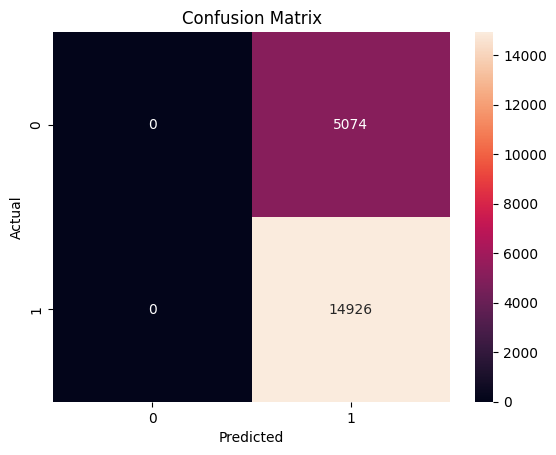

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()